# Data exploration of trace gasses dataset

## Data observation:

TODO: average to 10 minutes
eliminate peaks - in CO above 1000

december 2021

**non-standard file format**

`*.ag` is not standard file format (like `*.csv`). However, the files contain tab-separated values

**Data fragmentation and invalid files**
Data is fragmented in multiple files in multiple directories. Each valid file contains Timestamp, measured value and instrument health data. alongside files with measurement data, there are also log files.

**Inconsistent files structure** 
File header is in some cases comma-separated and in other cases tab separated

```
Time	CO(ppm)	p_sample(in-hg-a)	f_sample(ccm)	co_meas(mV)	co_ref(mV)	mr_ratio	t_bench(C)	t_wheel(C)	t_oven(C)	t_box(C)
```
vs.
```
Time,CO(ppm),p_sample(in-hg-a),f_sample(ccm),co_meas(mV),co_ref(mV),mr_ratio,t_bench(C),t_wheel(C),t_oven(C),t_box(C)
```

**Invalid timestamps**

Example on the 2nd line (`1.179`)
Example:
```
231129165004	1.179	48.0	62.0	46.0	40.8	0.404	25.5	1515.0	3267.9	2759.3	
1.179	25.5	1512.0	3267.8	2758.3	1.179	48.0	62.7	46.0	
231129165024	40.8	0.405	25.5	1514.0	3271.1	2761.3	1.179	48.0	61.8	46.0
```

**Corrupted files**

invalid characters ath the end of some files - manually corrected

Example files with corrupted content:
- `/Tvarminne/Trace_gases/CO/2025/CO_tele_250507.ag`
- `/Tvarminne/Trace_gases/CO/2025/CO_tele_250721.ag`

**Invalid recods** 

In file `/Tvarminne/Trace_gases/CO/2025/CO_tele_251110.ag`

```
251110050800	0.059	29.0	1687.0	4225.5	3555.9	1.18	47.9	62.0	46.0	40.8	
251110050820	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110050911	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051003	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051054	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051146	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
```

Many files miss value in many records.

**Inconsistency in column order**

SO2 has values in third column insted of second

```
Time		flag		SO2		hiso2		intt		rctt		pgast		pres		smplfl		pmtv		lmpv		lmpi
221221000047	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
221221000147	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
221221000247	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
```

## Data preprocessing

To address challenges indentified in manula data observation, raw data is preprocessed and saved as single parquet file for each measure. Log data is ignored as well as raws with invalid data (i.e. timestamp not convertabl to datetime)

As a result, there are 4 parquet files:

- CO.parquet
- NO.parquet
- O3.parquet
- SO2.parquet

Each *.parquet file contains "Time" column and 1-2 columns with measured values. Other column present in raw data are ignored.

___

Import of libraries, defined constants:

In [126]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator


DATA_BASE_PATH = "../local/Tvarminne/Trace_gases"

DATA_MAP = {
    "CO": {
        "columns" : ["CO"],
        "n": [1],
        "units": ["ppb"],
    },
    "NO": {
        "columns" : ["NO", "NO2"],
        "n": [1, 2],
        "units": ["ppb", "ppb"]
    },
    "O3": {
        "columns" : ["O3"],
        "n": [1],
        "units": ["ppb"]
    },
    "SO2": {
        "columns" : ["SO2"],
        "n": [2],
        "units": ["ppb"]
    }
}

MEASURE_LIMITS_MAX = {
    "CO": 1000,
}

SEASON_MAP = {
  12: "winter",
  1: "winter",
  2: "winter",
  3: "spring",
  4: "spring",
  5: "spring",
  6: "summer",
  7: "summer",
  8: "summer",
  9: "autumn",
  10: "autumn",
  11: "autumn"
}

PREPROCESS_SUBPATH = "preprocessed"
PREPROCESSED_DATA_PATH = f"{DATA_BASE_PATH}/{PREPROCESS_SUBPATH}"

Data preprocessing code - combining data into single file for each gas:

In [127]:
def preprocess_data():
    for gas, details in DATA_MAP.items():
        print(f"Preprocessing data for: {gas}...")
        print(f"details: {details}")
        path = Path(f"{DATA_BASE_PATH}/{gas}")
        files_to_process = path.glob("*/*.ag")
        dfs = []

        for file in files_to_process:
            # reading file, ignoring header
            df = pd.read_csv(file, skiprows=1, header=None, sep=r'\s+', engine='python')
            keep_cols = [0] + details["n"]  # always keep the first column (timestamp) and the columns specified in details
            df = df.iloc[:, keep_cols]

            # setting column names
            df.columns = ["Time"] + details["columns"]

            # Converting first column (timestamps) to numeric, coercing errors to NaN
            df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
            df["Time"] = pd.to_datetime(df["Time"], format='%y%m%d%H%M%S', errors='coerce')

            df.dropna(subset=["Time"], inplace=True)  # Drop rows where Time conversion failed

            for col in details["columns"]:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col] = df[col].mask(df[col] < 0, np.nan) 
                
            df = df.dropna(subset=details["columns"], how="all")
            # setting Time as index
            df.set_index("Time", inplace=True)
            # appending to list of dataframes for this gas
            dfs.append(df)
        
        df = pd.concat(dfs, ignore_index=False)
        df = df.sort_index()
        new_path = Path(f"{PREPROCESSED_DATA_PATH}/{gas}.parquet")
        new_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(new_path, index=True)
        print(f"Saved data for {gas} to {new_path}")

Trigerring data preprocessing only if not yet preprocessed - identified by existance of directory with preprocessed data:

In [128]:
preprocessd_data_path = Path(PREPROCESSED_DATA_PATH)
if not preprocessd_data_path.exists():
    print(f"Preprocessed data not found at {PREPROCESSED_DATA_PATH}. Starting preprocessing...")
    preprocess_data()
else:
    print(f"Preprocessed data already exists at {PREPROCESSED_DATA_PATH}. Skipping preprocessing.")

Preprocessed data already exists at ../local/Tvarminne/Trace_gases/preprocessed. Skipping preprocessing.


## Exploration on preprocessed data

Loading preprocessed data to dataframes

In [129]:
dfs = {}

for file in DATA_MAP.keys():
    df = pd.read_parquet(f"{PREPROCESSED_DATA_PATH}/{file}.parquet", engine="pyarrow")
    for col in df.columns:
        limit_max = MEASURE_LIMITS_MAX.get(col, None)
        if limit_max is not None:
            df[col] = df[col].clip(upper=limit_max)

    dfs[file] = df

dfs_daily = {key: df.resample("D").median() for key, df in dfs.items()}
dfs_10min = {key: df.resample("10min").median() for key, df in dfs.items()}

Side-by side comparison of measured data

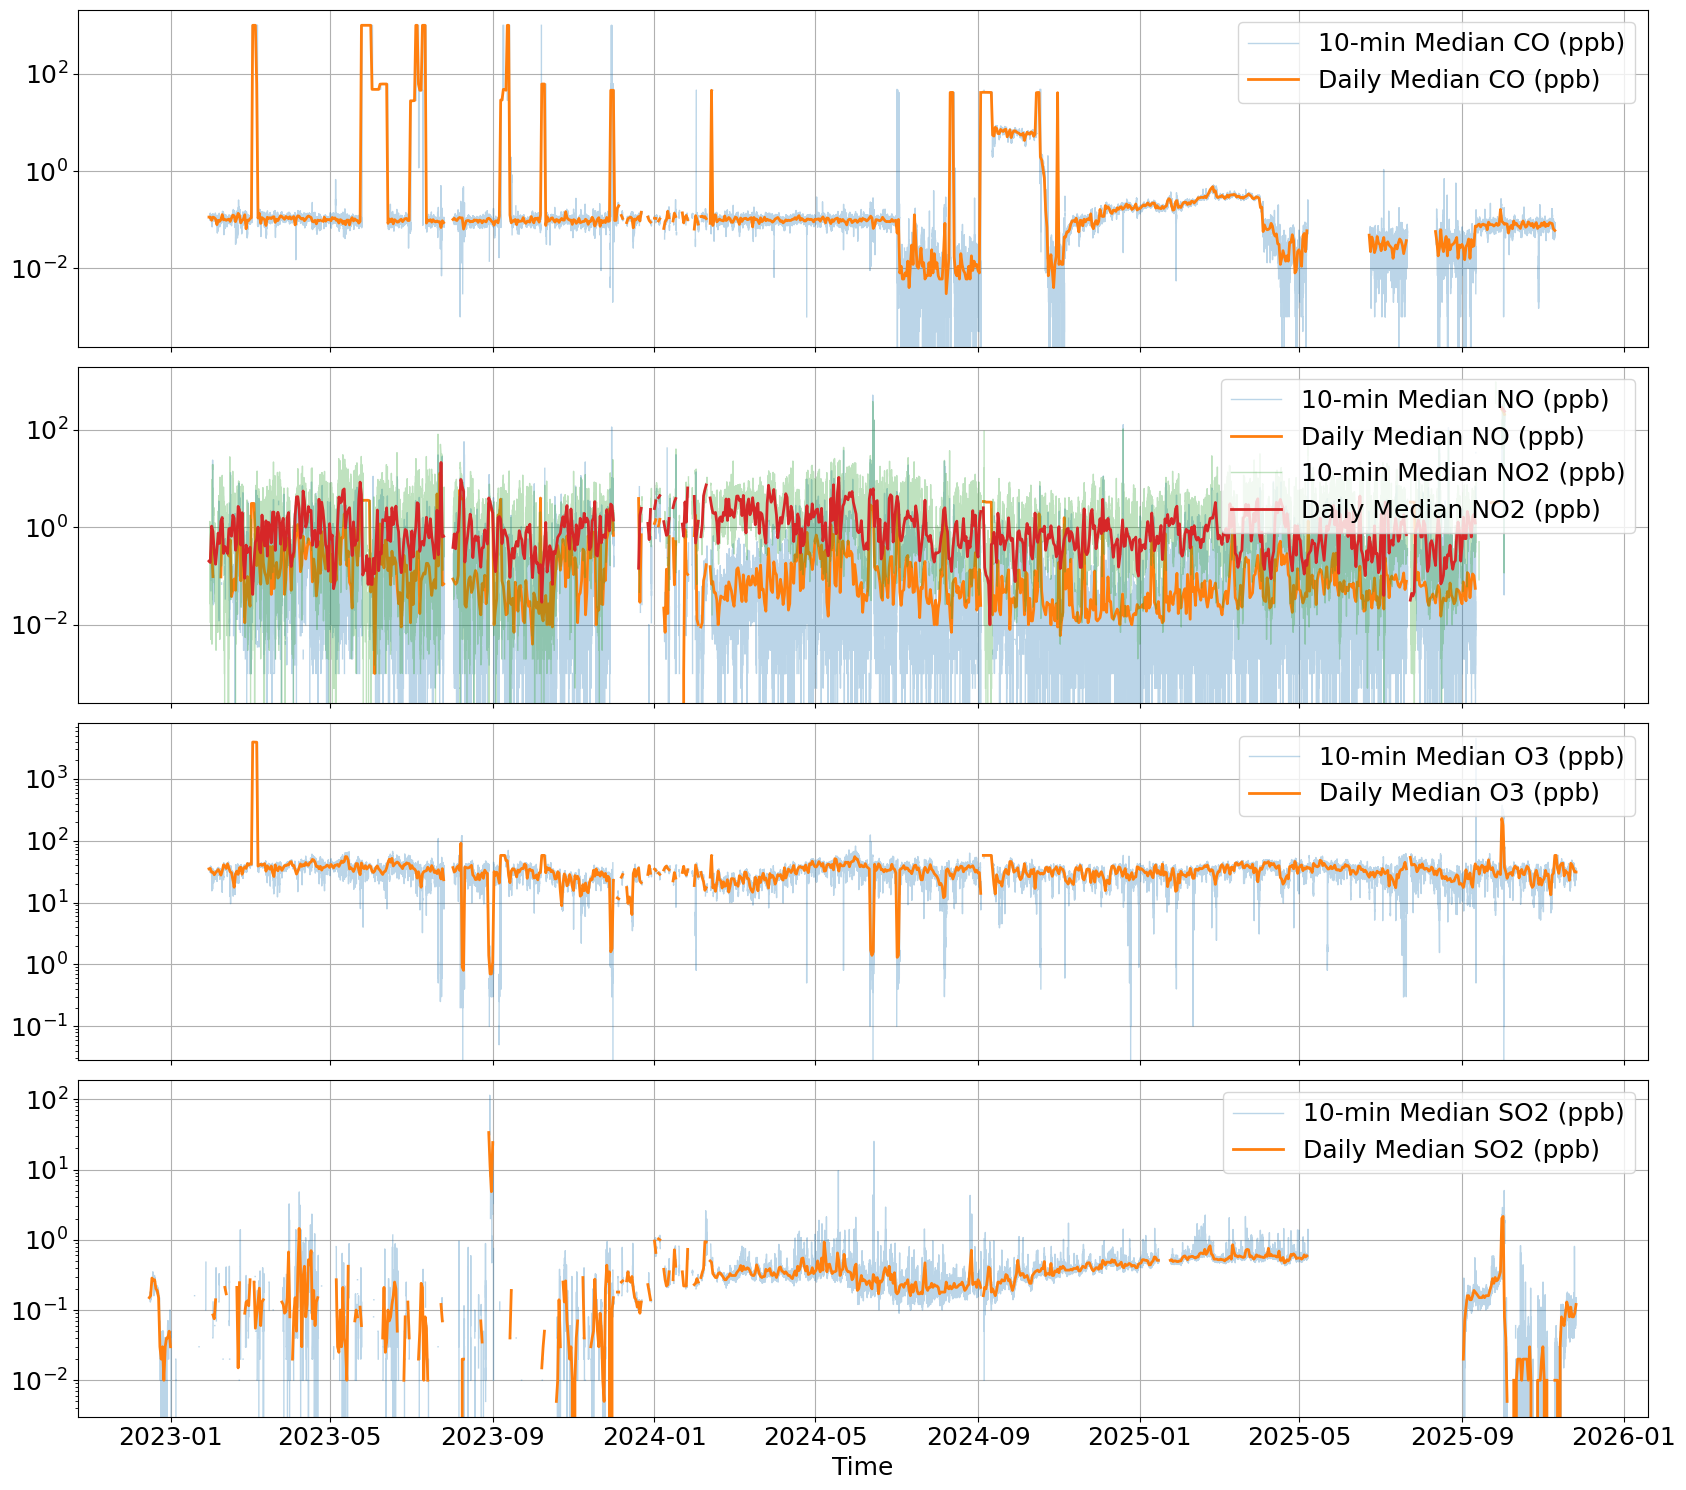

In [ ]:
fig, axes = plt.subplots(
    len(dfs),
    1,
    figsize=(17, 15),
    sharex=True,
)

# fig.suptitle("Trace gasses")

ax_n = 0
for file, detail in DATA_MAP.items():
    ax = axes[ax_n]
    ax_n += 1

    df = dfs[file]
    df_daily = dfs_daily[file]
    df_10min = dfs_10min[file]
    
    col_unit = zip(detail["columns"], detail["units"])
    
    for col, unit in col_unit:
        values = df[col]
        # ax.plot(df.index, values, label=f"{col} ({unit})", marker='o', markersize=2, linestyle='None', alpha=0.1)
        ax.plot(df_10min.index, df_10min[col],
            marker='o', markersize=0,
            linewidth=1, alpha=0.3,
            label=f"10-min Median {col} ({unit})")
        ax.plot(df_daily.index, df_daily[col],
            marker='o', markersize=0,
            linewidth=2,
            label=f"Daily Median {col} ({unit})")
    ax.set_yscale("log")

    ax.legend(loc="upper right", fontsize=18)
    ax.grid(True)
    ax.yaxis.set_major_locator(LogLocator(numticks=5))
    ax.tick_params(axis='both', labelsize=18)

plt.xlabel("Time", fontsize=18)
plt.tight_layout()
plt.show()

In [131]:
## Combine hourly

In [140]:
df_hourly = {key: df.resample("h").median() for key, df in dfs.items()}

df_hourly_combined = pd.concat(df_hourly.values(), axis=1,)

print(df_hourly_combined.index.dtype)

new_columns = df_hourly_combined.columns

df_hourly_combined.columns = [
    f"{col}_ppb" for col in df_hourly_combined.columns
]

print(df_hourly_combined.head())

df_hourly_combined.to_csv("trace_gasses.csv", index=True, date_format="%Y-%m-%d %H:%M:%S")


/var/folders/4n/yppqqwjx1c3dm2wcldv4t8ch0000gn/T/ipykernel_45571/389482677.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_hourly_combined = pd.concat(df_hourly.values(), axis=1,)


datetime64[us]
                     CO_ppb  NO_ppb  NO2_ppb  O3_ppb  SO2_ppb
Time                                                         
2022-12-16 15:00:00     NaN     NaN      NaN     NaN     0.18
2022-12-16 16:00:00     NaN     NaN      NaN     NaN     0.16
2022-12-16 17:00:00     NaN     NaN      NaN     NaN     0.14
2022-12-16 18:00:00     NaN     NaN      NaN     NaN     0.18
2022-12-16 19:00:00     NaN     NaN      NaN     NaN     0.13
